<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/kmeans_iris_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering on Iris Dataset
Complete Colab-ready notebook with preprocessing, optimal K selection, clustering, and visualization.

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print('Shape:', X.shape)

Shape: (150, 4)


In [ ]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

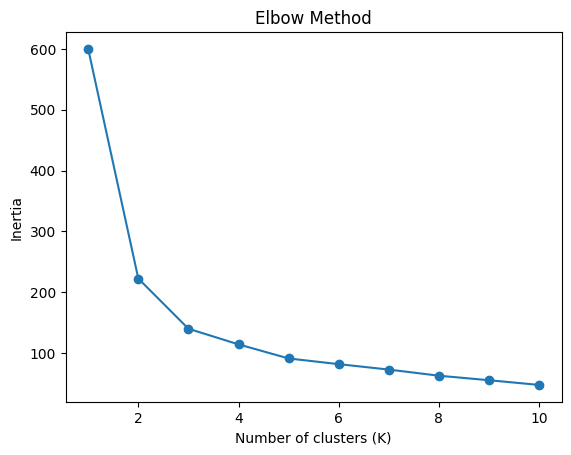

In [ ]:
# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()



> Elbow shows clear knee at K=3



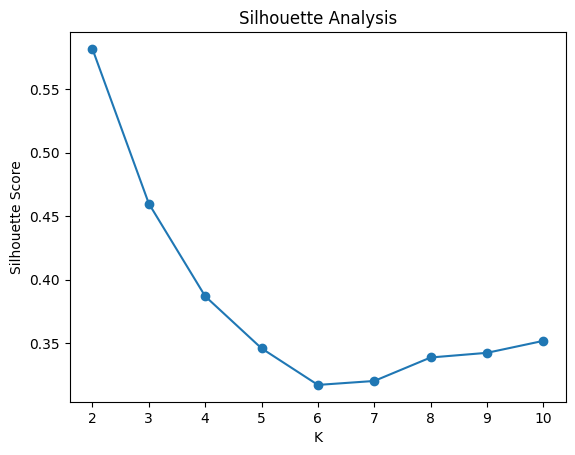

In [ ]:
# Silhouette Score
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()



> Although silhouette score peaks at K=2, we select K=3 to align with the known class structure of the Iris dataset.



**Iris has:**

Setosa → well-separated

Versicolor & Virginica → overlapping

**So:**

Silhouette prefers 2 clusters
Elbow detects structure of 3 group

In [ ]:
# Final KMeans (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

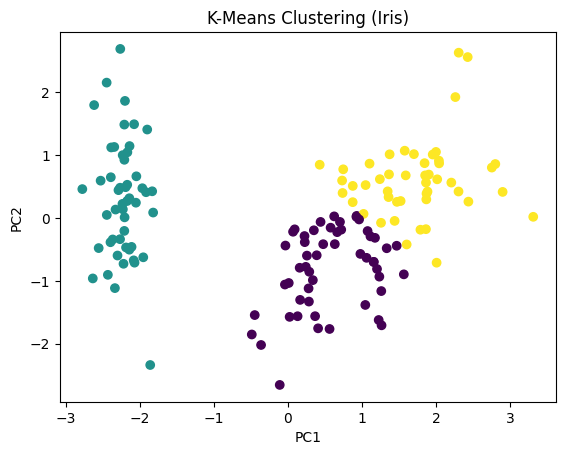

In [ ]:
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (Iris)')
plt.show()



---



New data point (example)

In [ ]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

Apply SAME preprocessing

In [ ]:
new_sample_scaled = scaler.transform(new_sample)

Predict cluster

In [ ]:
cluster = kmeans.predict(new_sample_scaled)

print("Assigned Cluster:", cluster[0])

Assigned Cluster: 1


or

In [ ]:
# def predict_cluster(new_sample, scaler, kmeans):
#     new_sample = np.array(new_sample).reshape(1, -1)
#     new_scaled = scaler.transform(new_sample)
#     cluster = kmeans.predict(new_scaled)
#     return cluster[0]

# # Example
# sample = [5.1, 3.5, 1.4, 0.2]
# print(predict_cluster(sample, scaler, kmeans))